# Pre-requisites

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
from torch.utils.data import WeightedRandomSampler

from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

Device: cuda


# Data pre-processing and EDA

In [ ]:
file_path='Multilingual_sentiment_analysis.csv'
df = pd.read_csv(file_path,encoding='utf-8')

df.head(10)

,Sentence,Label
0,The crisis management team is still assessing ...,Neutral
1,ಅಗತ್ಯವಿರುವವರಿಗೆ ಪರಿಹಾರ ಸಾಮಗ್ರಿಗಳನ್ನು ವಿತರಿಸಲಾಗ...,Neutral
2,தொலைக்காட்சியில் நீதிமன்ற நாடகங்கள் வழக்கறிஞர்...,Positive
3,இந்த மாதத்திற்கான ஊதியத்தை hr துறை சரியான நேரத...,Neutral
4,টুইটারে গ্রাহক পরিষেবা খুব সহায়ক এবং বন্ধুত্ব...,Positive
5,ମାନସିକ ସ୍ୱାସ୍ଥ୍ୟ ସମ୍ବଳରେ ଆମ କମ୍ପାନୀର ବିନିଯୋଗ କ...,Positive
6,வாடிக்கையாளர் சேவை வலைத்தளத்தில் எனது கேள்விகள...,Positive
7,"ఉత్పత్తి మంచి, కానీ పోటీదారులు వంటి మంచి కాదు.",Neutral
8,আমাদের কর্মীরা দল গঠনের ক্রিয়াকলাপের সময় অত্...,Positive
9,রাজনৈতিক সমাবেশটি বিভিন্ন গোষ্ঠীর মধ্যে ঐক্য ও...,Positive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131044 entries, 0 to 131043
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   Sentence  131018 non-null  object
 1   Label     131018 non-null  object
dtypes: object(2)
memory usage: 2.0+ MB


In [4]:
df.isnull().sum()

Sentence    26
Label       26
dtype: int64

In [5]:
df['Label'].value_counts()

Label
Positive    52517
Negative    45981
Neutral     32520
Name: count, dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.rename(columns={'Sentence': 'text', 'Label': 'label'}, inplace=True)
df = df.dropna()
df = df[df["text"].str.strip() != ""]

#Label Encoding
df['label'].replace({'Positive':0,'Neutral':1,"Negative":2},inplace=True)
df['label'] = df['label'].astype(int)

texts = df['text'].tolist()
labels = df['label'].tolist()

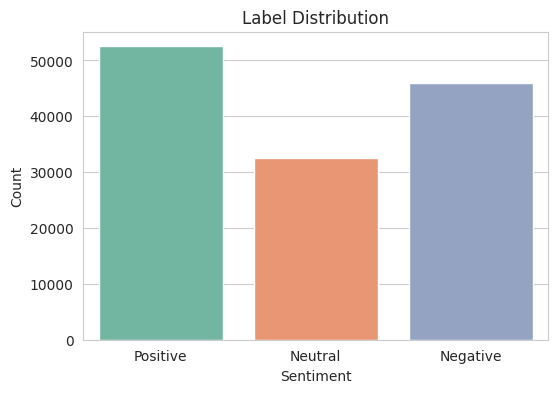

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df, palette='Set2')

plt.title("Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks([0,1,2], ["Positive", "Neutral", "Negative"])

plt.show()

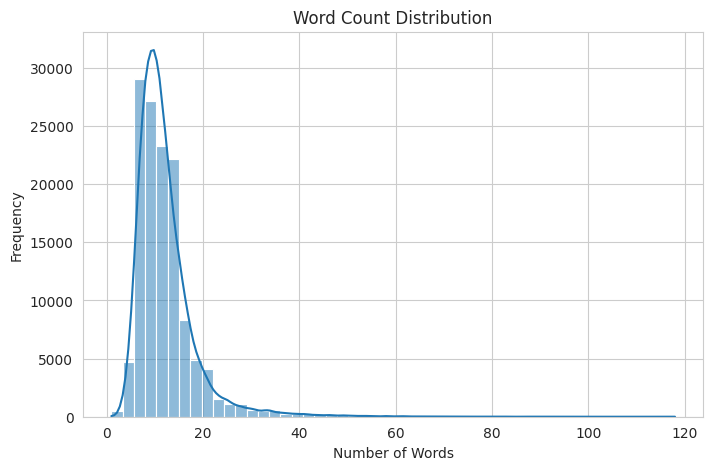

In [9]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))

sns.histplot(df['word_count'], bins=50, kde=True,palette='viridis')

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

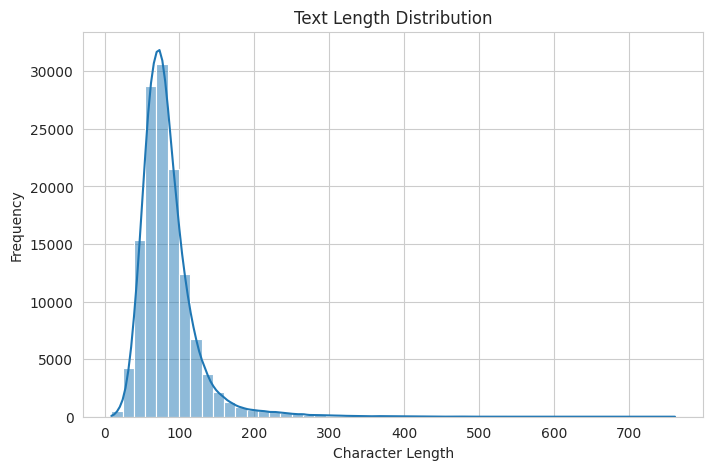

In [10]:
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(8,5))

sns.histplot(df['text_length'], bins=50, kde=True)

plt.title("Text Length Distribution")
plt.xlabel("Character Length")
plt.ylabel("Frequency")

plt.show()

In [11]:
#Train-test split
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

In [12]:
#Downsampling the test class

test_pos = test_df[test_df.label == 0]
test_neu = test_df[test_df.label == 1]
test_neg = test_df[test_df.label == 2]

min_size = min(len(test_pos), len(test_neu), len(test_neg))

test_balanced = pd.concat([
    test_pos.sample(min_size, random_state=42),
    test_neu.sample(min_size, random_state=42),
    test_neg.sample(min_size, random_state=42)
]).sample(frac=1).reset_index(drop=True)

In [13]:
print("Train Dataset:")
train_df['label'].value_counts()

Train Dataset:


label
0    42013
2    36785
1    26016
Name: count, dtype: int64

In [14]:
print("Test Dataset:")
test_balanced['label'].value_counts()

Test Dataset:


label
0    6504
2    6504
1    6504
Name: count, dtype: int64

In [19]:
train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()

test_texts = test_balanced['text'].tolist()
test_labels = test_balanced['label'].tolist()

# Loading pre-trained models (XLM-R,LaBSE)

In [20]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

In [21]:
xlm = AutoModel.from_pretrained("xlm-roberta-base")
for param in xlm.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
labse = SentenceTransformer('sentence-transformers/LaBSE')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Pre-loading the LaBSE encodings (for faster training)

In [23]:
labse_embeddings = labse.encode(train_texts,
                                batch_size=32, 
                                show_progress_bar=True,
                                convert_to_numpy=True)

Batches:   0%|          | 0/3276 [00:00<?, ?it/s]

# Loading the dataset

In [24]:
#Weighted sampling for train dataset

labels_np = np.array(train_labels)
class_counts = np.bincount(labels_np)
class_weights = 1. / class_counts
sample_weights = class_weights[labels_np]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [25]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer,labse_embeds=None, max_len=64,train=True):
        self.texts = texts
        self.labels = labels
        self.labse_embeds = labse_embeds
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.train = train

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        item = {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

        if self.train:
            item['labse'] = torch.tensor(self.labse_embeds[idx], dtype=torch.float32)
        
        if not self.train:
            item['text'] = text

        return item

In [26]:
train_dataset = TextDataset(train_texts, train_labels, tokenizer,labse_embeddings,train=True)
test_dataset = TextDataset(test_texts, test_labels, tokenizer,labse_embeddings,train=False)

train_loader = DataLoader(train_dataset, batch_size=32,sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Building the Model

In [27]:
class FusionModel(nn.Module):
    def __init__(self, xlm, hidden_dim=256, labse_dim=768):
        super().__init__()
        self.xlm = xlm

        self.gru=nn.GRU(
            input_size=768,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.labse_proj = nn.Linear(labse_dim, hidden_dim)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2 + hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )

    def forward(self, input_ids, attention_mask, labse_emb):

        with torch.no_grad():
            outputs = self.xlm(input_ids=input_ids, attention_mask=attention_mask)
            H = outputs.last_hidden_state   # (B, T, 768)

        H_gru, _ = self.gru(H)
        h_seq = H_gru.mean(dim=1)  
        
        h_labse = self.labse_proj(labse_emb)  

        h_final = torch.cat([h_seq, h_labse], dim=1)

        return self.classifier(h_final)

In [28]:
model = FusionModel(xlm).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.CrossEntropyLoss()

In [29]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters: {total - trainable:,}")

Total parameters: 280,014,083
Trainable parameters: 1,970,435
Frozen parameters: 278,043,648


In [30]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        labse_emb = batch['labse'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask, labse_emb)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        acc = correct / total

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{acc:.4f}"
        })

    return total_loss / len(loader), acc

# Training the Model

In [31]:
EPOCHS = 5

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    loss = train_epoch(model, train_loader)


Epoch 1/5


Training:   0%|          | 0/3276 [00:00<?, ?it/s]


Epoch 2/5


Training:   0%|          | 0/3276 [00:00<?, ?it/s]


Epoch 3/5


Training:   0%|          | 0/3276 [00:00<?, ?it/s]


Epoch 4/5


Training:   0%|          | 0/3276 [00:00<?, ?it/s]


Epoch 5/5


Training:   0%|          | 0/3276 [00:00<?, ?it/s]

# Evaluating the Model

In [34]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            text=batch['text']

            labse_emb = torch.tensor(
                labse.encode(text,convert_to_numpy=True),
                dtype=torch.float32
            ).to(device)

            outputs = model(input_ids, attention_mask, labse_emb)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

In [35]:
preds, true = evaluate(model, test_loader)

Evaluating:   0%|          | 0/610 [00:00<?, ?it/s]

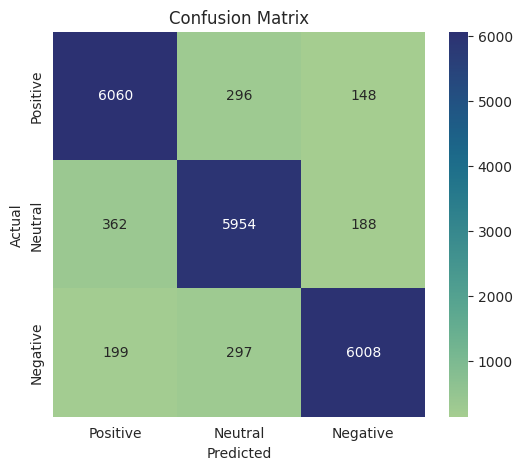

In [36]:
#Confusion Matrix
cm = confusion_matrix(true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="crest",
            xticklabels=["Positive","Neutral","Negative"],
            yticklabels=["Positive","Neutral","Negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

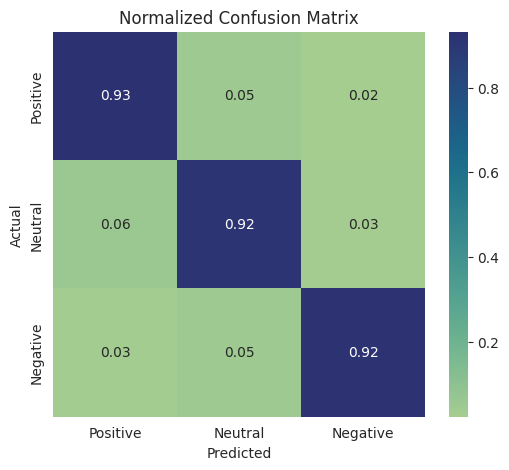

In [37]:
#Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="crest",
            xticklabels=["Positive","Neutral","Negative"],
            yticklabels=["Positive","Neutral","Negative"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix")

plt.show()

In [38]:
#Classification Report
print(classification_report(true, preds, target_names=["Positive","Neutral","Negative"]))

              precision    recall  f1-score   support

    Positive       0.92      0.93      0.92      6504
     Neutral       0.91      0.92      0.91      6504
    Negative       0.95      0.92      0.94      6504

    accuracy                           0.92     19512
   macro avg       0.92      0.92      0.92     19512
weighted avg       0.92      0.92      0.92     19512

